# Effect inference with timeseries data

In this notebook, we will look at an example of causal effect inference from timeseries data. We will use DoWhy's functionality to add temporal dependencies to a causal graph and estimate causal effect based on the augmented graph.  

## Loading timeseries data and causal graph

In [11]:
import numpy as np
import pandas as pd

def v2_relation(v1, v2_1 ):
    v2 = None
    if v1 > 80:
       v2 = -1
    elif v1 < 30:
        v2 = 1
    else:
        v2 = v2_1

    return v2
n = 1000

V1 = np.empty((n, 1))
V1[0, 0] = 30

V2 = np.empty((n, 1))
V2[0, 0] = 1

for i in range(1, n):
    # v1
    V1[i, 0] = V1[i - 1, 0] + 0.5 * V2[i - 1, 0] + np.random.normal(0, 0.5)
    # v2
    V2[i, 0] = v2_relation(V1[i, 0] ,V2[i-1, 0] )


dataframe1 = pd.DataFrame(
    np.concatenate([V1, V2], axis=1), columns=["V1", "V2"]
)

In [12]:
import math
import numpy as np
import pandas as pd

n = 1000

V1 = np.empty((n, 1))
V1[0, 0] = 0
V2 = np.empty((n, 1))
V2[0,0] = V1[0,0] * 0.5 + np.random.normal(0, 0.5)
V3 = np.empty((n, 1))
V3[0,0] =  math.sqrt(abs(V2[0,0] )) 
if V2[0, 0] < 0:
    V3[0, 0] *= -1 

for i in range(1, n):
    V1[i, 0]  = V3[i-1,0] *2 + np.random.normal(0, 1)
    V2[i,0] =  V1[i,0] * 0.5 + np.random.normal(0, 0.5)
    V3[i,0] =  math.sqrt(abs(V2[i,0] )) 
    if V2[i, 0] < 0:
        V3[i, 0] *= -1 



dataframe2 = pd.DataFrame(
    np.concatenate([V1, V2,V3], axis=1), columns=["V1", "V2","V3"]
)

<Axes: >

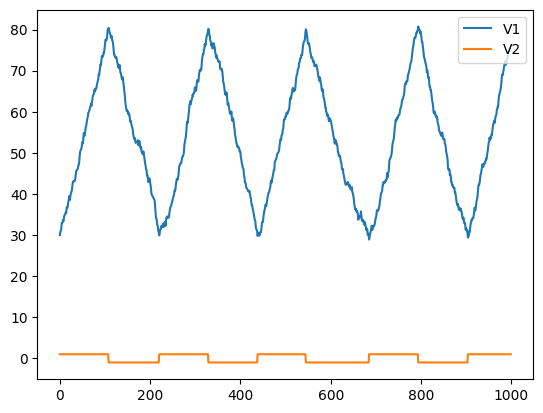

In [13]:
dataframe = dataframe1
dataframe.plot()

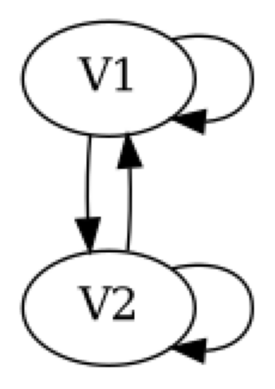

In [14]:
from dowhy.utils.timeseries import create_graph_from_csv
from dowhy.utils.plotting import plot

# Input a csv file with the edges in the graph with the columns: node_1,node_2,time_lag
file_path = "../datasets/temporal_graph.2.csv"

# Create the graph from the CSV file
graph = create_graph_from_csv(file_path)
plot(graph)

In [15]:
from dowhy import gcm

causal_model = gcm.StructuralCausalModel(graph=graph)

In [16]:
from dowhy.gcm.defined_causal_mechanisms import DefinedConditionalStochasticModel


# causal_model.set_causal_mechanism("V1",DefinedConditionalStochasticModel(relation=lambda x: x[:,0]+ 0.5 *x[:,1], noise= lambda: np.random.normal(0,0.5)))

causal_model.set_causal_mechanism("V2",DefinedConditionalStochasticModel(relation=lambda x: np.array( v2_relation(x[-1,0],x[-1,1]))))

In [17]:
aas = gcm.auto.assign_causal_mechanisms(causal_model, dataframe,override_models=False)
print(aas)

When using this auto assignment function, the given data is used to automatically assign a causal mechanism to each node. Note that causal mechanisms can also be customized and assigned manually.
The following types of causal mechanisms are considered for the automatic selection:

If root node:
An empirical distribution, i.e., the distribution is represented by randomly sampling from the provided data. This provides a flexible and non-parametric way to model the marginal distribution and is valid for all types of data modalities.

If non-root node and the data is continuous:
Additive Noise Models (ANM) of the form X_i = f(PA_i) + N_i, where PA_i are the parents of X_i and the unobserved noise N_i is assumed to be independent of PA_i.To select the best model for f, different regression models are evaluated and the model with the smallest mean squared error is selected.Note that minimizing the mean squared error here is equivalent to selecting the best choice of an ANM.

If non-root node

In [18]:
cmer = gcm.fit(causal_model, dataframe,return_evaluation_summary=False,)
print(cmer)

Fitting causal mechanism of node V2: 100%|██████████| 2/2 [00:00<00:00,  9.96it/s]

None


In [19]:
samples = gcm.draw_samples_incremental(causal_model,num_samples=1000,observed_data=dataframe.head(100))

Using intial sample for V1 at row 0.
Using intial sample for V2 at row 0.
Using intial sample for V1 at row 1.
Using intial sample for V2 at row 1.
Using intial sample for V1 at row 2.
Using intial sample for V2 at row 2.
Using intial sample for V1 at row 3.
Using intial sample for V2 at row 3.
Using intial sample for V1 at row 4.
Using intial sample for V2 at row 4.
Using intial sample for V1 at row 5.
Using intial sample for V2 at row 5.
Using intial sample for V1 at row 6.
Using intial sample for V2 at row 6.
Using intial sample for V1 at row 7.
Using intial sample for V2 at row 7.
Using intial sample for V1 at row 8.
Using intial sample for V2 at row 8.
Using intial sample for V1 at row 9.
Using intial sample for V2 at row 9.
Using intial sample for V1 at row 10.
Using intial sample for V2 at row 10.
Using intial sample for V1 at row 11.
Using intial sample for V2 at row 11.
Using intial sample for V1 at row 12.
Using intial sample for V2 at row 12.
Using intial sample for V1 at ro

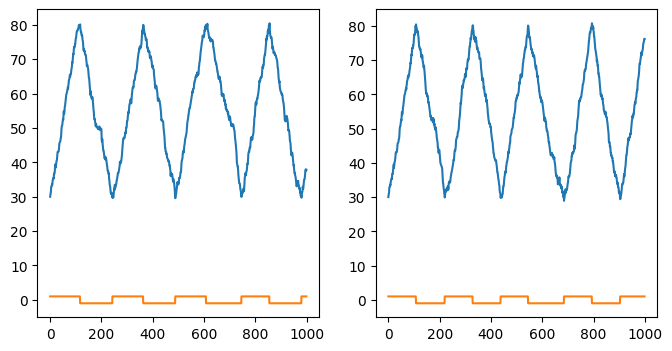

In [20]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(ncols=2,figsize=(8,4))

ax[0].plot(samples)

ax[1].plot(dataframe1)